In [41]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\BCI_classifier


In [31]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns

In [32]:
folder = r"C:\Users\hodor\Documents\lab-Shishkin\projects\astrosync-im-vs-qm\astrosync-analysis\data\raw\exp"
subjects = os.listdir(folder)
for subject in subjects:
    calibs = os.listdir(os.path.join(folder, subject))
    calibs = [calib for calib in calibs if calib.find('_calib.hdf') != -1]
    print(subject, calibs)

01TG ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
02ES ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
03AC ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
04AB ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
06KK ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
07TS ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
10AS ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
11AK ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
13AU ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
14BE ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
15AZ ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
18KK ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
19VB ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
20EC ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
21EC ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
22ES ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
23MM ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
24EK ['im_rec_calib.hdf', 'qm_rec_calib.hdf']
25PP ['im_rec_calib.hdf', 'qm_rec_calib.hdf']


In [48]:
folder_output = r"..\data\pr_AstoSync\raw\exp"
for subject in subjects:
    os.makedirs(os.path.join(folder_output, subject), exist_ok=True)

In [33]:
filename = os.path.join(folder, subject, calibs[0])
with File(filename, "r") as h5f:
    print(h5f["eeg"].keys())
    data = h5f["eeg"]["data"][:-1, :]

<KeysViewHDF5 ['blocks', 'data', 'streamInfo']>


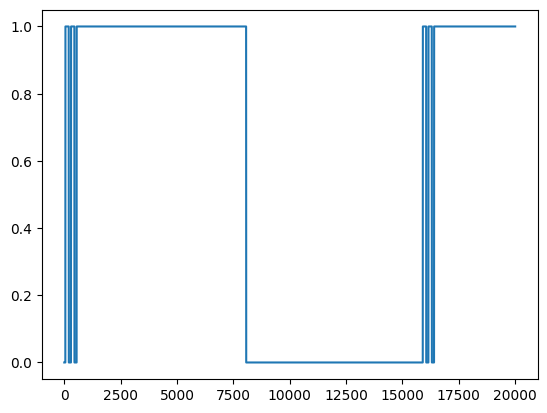

In [34]:
trigger = data[:, -1]
def ttl2binary(ttl_signal, bit_index=0):
    ttl = np.array(ttl_signal, dtype=np.uint8)
    return ((ttl>>bit_index) & 0b1).astype(int)
trigger = ttl2binary(trigger, bit_index=0)
trigger = 1 - trigger
start = 30000
dur = 20000
plt.plot(trigger[start:start+dur])

In [43]:
def define_label(dtrigger, idx, buff=600, labels={1: 0, 2: 1, 3: 2}):
        dtrig = dtrigger[idx-buff:idx-10] 
        n_shifts = np.where(dtrig == 1)[0].shape[0]
        for key in labels:
            if n_shifts == key:
                return labels[key]
        return np.nan

def parse_events(trigger, window_size=200, baseline=100, end_shift=100):
    strigger = np.convolve(trigger, np.ones(window_size, dtype=int), 'valid')   # sum of trigger in window  
    
    start_idx = np.where((strigger == window_size) & (np.diff(strigger, prepend=0) == 1))[0].reshape((-1, 1))
    end_idx = np.where((strigger == 0) & (np.diff(strigger, prepend=0) == -1))[0].reshape((-1, 1))

    dtrigger = np.diff(trigger)
    labels = np.array([define_label(dtrigger, idx[0]) for idx in start_idx])

    events = np.concatenate([start_idx-baseline, end_idx+end_shift], axis=1)

    idxs1 = events[labels == 0]
    idxs2 = events[labels == 1]
    idxs3 = events[labels == 2]
    
    # for quasi feedback
    # start_idx = (idxs2[:, 1] + 4000).reshape((-1, 1))
    # end_idx = (start_idx + 8000).reshape((-1, 1))
    # idxs1 = np.concatenate([start_idx, end_idx], axis=1)
    
    return idxs1, idxs2, idxs3

idxs1, idxs2, idxs3 = parse_events(trigger, window_size=200, baseline=500)

In [45]:
idxs1.shape, idxs2.shape, idxs3.shape

((20, 2), (20, 2), (0, 2))

In [50]:
np.asarray(subjects)

array(['01TG', '02ES', '03AC', '04AB', '06KK', '07TS', '10AS', '11AK',
       '13AU', '14BE', '15AZ', '18KK', '19VB', '20EC', '21EC', '22ES',
       '23MM', '24EK', '25PP'], dtype='<U4')

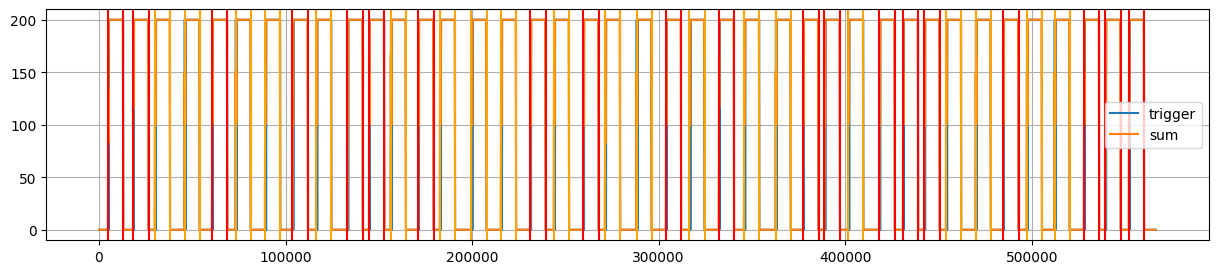

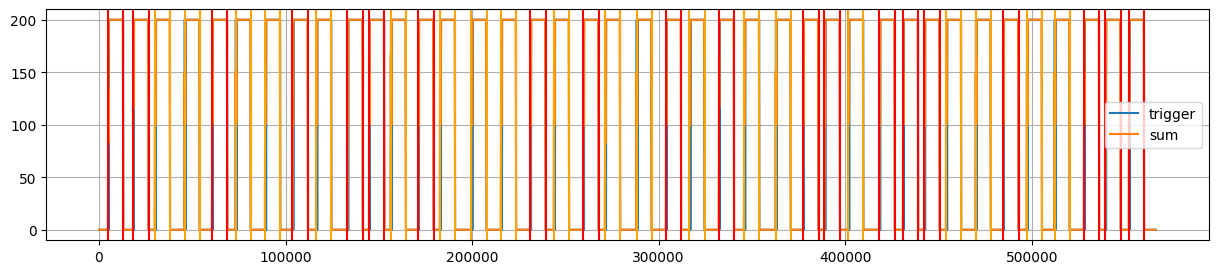

In [46]:
def plot_events(trigger, idxs1, idxs2, idxs3, window_size=200, xrange=None):
    strigger = np.convolve(trigger, np.ones(window_size, dtype=int), 'valid')

    n = 1
    fig, ax = plt.subplots(n, 1, figsize=(15, 3), sharex=True)

    ax.plot(trigger * window_size, label="trigger")
    ax.plot(strigger, label="sum")

    colors = ['red', 'orange', 'green']
    for color, idxs in zip(colors, [idxs1, idxs2, idxs3]):
        for idx in idxs:
            ax.axvline(idx[0], color=color)
            ax.axvline(idx[1], color=color)

    ax.legend()

    ax.grid()
    if xrange is not None:
        ax.set_xlim(xrange) 
    plt.show(block=True)
    return fig

plot_events(trigger, idxs1, idxs2, idxs3)